<a href="https://colab.research.google.com/github/Rakshithbodakuntla/ML_/blob/main/cv%2C_grid_search_cv%2C_randomised_search_cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv('adult.csv')
display(df.head())

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [50]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB
None
age                0
workclass          0
fnlwgt             0
educatio

In [51]:
# Replace '?' with np.nan for relevant columns
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].replace('?', np.nan)

print('\nNull counts after replacing \'?\':')
print(df.isnull().sum())


Null counts after replacing '?':
age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [52]:
# Impute missing values with the mode for categorical columns
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df.isnull().sum())

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


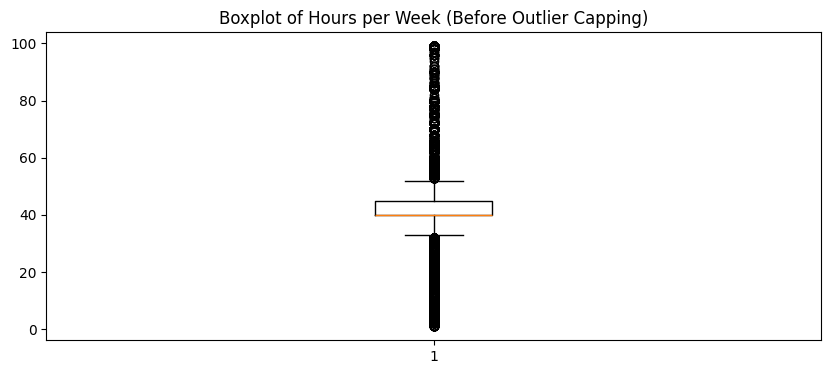

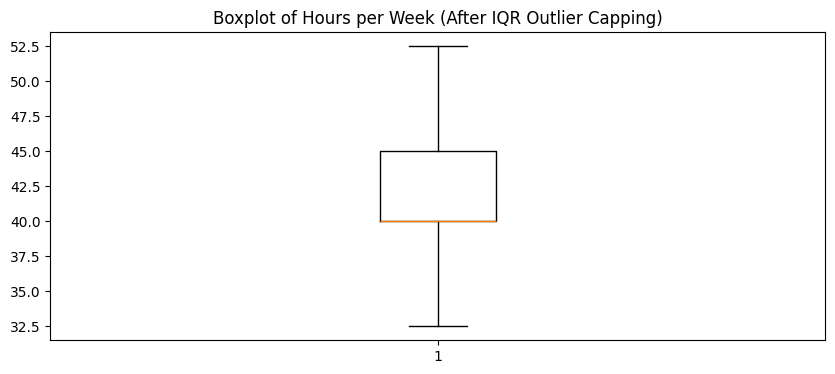

In [53]:
plt.figure(figsize=(10, 4))
plt.boxplot(df['hours-per-week'])
plt.title('Boxplot of Hours per Week (Before Outlier Capping)')
plt.show()

Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

df['hours-per-week'] = df['hours-per-week'].clip(lower=lower_bound, upper=upper_bound)

plt.figure(figsize=(10, 4))
plt.boxplot(df['hours-per-week'])
plt.title('Boxplot of Hours per Week (After IQR Outlier Capping)')
plt.show()

In [54]:
# Drop irrelevant/redundant columns for features (x)
x = df.drop(['fnlwgt', 'educational-num', 'marital-status', 'relationship', 'race', 'income'], axis=1)

# Encode the target variable 'income' to 0 and 1
y = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

display(x.head())
display(y.head())

,age,workclass,education,occupation,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,11th,Machine-op-inspct,Male,0,0,40.0,United-States
1,38,Private,HS-grad,Farming-fishing,Male,0,0,50.0,United-States
2,28,Local-gov,Assoc-acdm,Protective-serv,Male,0,0,40.0,United-States
3,44,Private,Some-college,Machine-op-inspct,Male,7688,0,40.0,United-States
4,18,Private,Some-college,Prof-specialty,Female,0,0,32.5,United-States


,income
0,0
1,0
2,1
3,1
4,0


In [61]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = x.select_dtypes(include=['object']).columns
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform on the full feature set x
x_encoded = ohe.fit_transform(x[categorical_cols])
x_encoded_df = pd.DataFrame(x_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=x.index)

# Drop original categorical columns and concatenate encoded ones
x = x.drop(columns=categorical_cols)
x = pd.concat([x, x_encoded_df], axis=1)

print(f"Shape of features after one-hot encoding: {x.shape}")
display(x.head())

Shape of features after one-hot encoding: (48842, 85)


,age,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,0,0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,38,0,0,50.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,28,0,0,40.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,44,7688,0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,18,0,0,32.5,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [63]:
from sklearn.model_selection import train_test_split

# Split the preprocessed data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (39073, 85)
x_test shape: (9769, 85)
y_train shape: (39073,)
y_test shape: (9769,)


In [64]:
x

,age,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,0,0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,38,0,0,50.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,28,0,0,40.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,44,7688,0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,18,0,0,32.5,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,0,0,38.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48838,40,0,0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48839,58,0,0,40.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
48840,22,0,0,32.5,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(log_reg, x_train, y_train, cv=5, scoring='accuracy')

print(f"Logistic Regression Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# Store results
results = []
results.append({'Model': 'Logistic Regression (Baseline)', 'CV Accuracy': cv_scores.mean(), 'Test Accuracy': np.nan, 'Best Params': 'N/A'})

results_df = pd.DataFrame(results)
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression Cross-Validation Scores: [0.83403711 0.82252079 0.83621241 0.82518556 0.82467366]
Mean CV Accuracy: 0.8285


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,CV Accuracy,Test Accuracy,Best Params
0,Logistic Regression (Baseline),0.828526,NaN,N/A


In [66]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

# Instantiate and fit GridSearchCV
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_lr.fit(x_train, y_train)

# Evaluate
test_accuracy_lr_gs = grid_search_lr.best_estimator_.score(x_test, y_test)

# Update results
results.append({'Model': 'Logistic Regression (GridSearch)', 'CV Accuracy': grid_search_lr.best_score_, 'Test Accuracy': test_accuracy_lr_gs, 'Best Params': grid_search_lr.best_params_})
results_df = pd.DataFrame(results)
display(results_df)

,Model,CV Accuracy,Test Accuracy,Best Params
0,Logistic Regression (Baseline),0.828526,NaN,N/A
1,Logistic Regression (GridSearch),0.828449,0.834272,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}"


### Hyperparameter Tuning: RandomizedSearchCV for Logistic Regression

To complement GridSearchCV, I'll also run RandomizedSearchCV. This can be more efficient for larger parameter spaces, as it samples a fixed number of parameter settings from specified distributions.

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

# Define parameter distributions
param_dist_lr = {
    'C': uniform(0.1, 10),
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

# Instantiate and fit RandomizedSearchCV
rand_search_lr = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_distributions=param_dist_lr, n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)
rand_search_lr.fit(x_train, y_train)

# Evaluate
test_accuracy_lr_rand = rand_search_lr.best_estimator_.score(x_test, y_test)

# Update results
results.append({'Model': 'Logistic Regression (RandomizedSearch)', 'CV Accuracy': rand_search_lr.best_score_, 'Test Accuracy': test_accuracy_lr_rand, 'Best Params': rand_search_lr.best_params_})
results_df = pd.DataFrame(results)
display(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,CV Accuracy,Test Accuracy,Best Params
0,Logistic Regression (Baseline),0.828526,NaN,N/A
1,Logistic Regression (GridSearch),0.828449,0.834272,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}"
2,Logistic Regression (RandomizedSearch),0.828705,0.833350,"{'C': 1.934347898661638, 'penalty': 'l2', 'sol..."


In [68]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

# CV and Test evaluation
rf_cv_scores = cross_val_score(rf_model, x_train, y_train, cv=5, n_jobs=-1)
rf_test_acc = rf_model.score(x_test, y_test)

# Final results update
results.append({'Model': 'Random Forest (Ensemble)', 'CV Accuracy': rf_cv_scores.mean(), 'Test Accuracy': rf_test_acc, 'Best Params': 'Default'})

results_df = pd.DataFrame(results)
print("\nSummary Table:")
display(results_df)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Summary Table:


,Model,CV Accuracy,Test Accuracy,Best Params
0,Logistic Regression (Baseline),0.828526,NaN,N/A
1,Logistic Regression (GridSearch),0.828449,0.834272,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}"
2,Logistic Regression (RandomizedSearch),0.828705,0.833350,"{'C': 1.934347898661638, 'penalty': 'l2', 'sol..."
3,Random Forest (Ensemble),0.817675,0.822807,Default
